In [2]:
import mne
from mne.preprocessing import ICA
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc
from scipy.signal import convolve
from scipy.ndimage import convolve1d
import seaborn as sns

In [3]:
subject1 = sc.io.loadmat("../data/s1.mat")
data1 = subject1['eeg']
data1 = data1.transpose(0,3,1,2)
print(np.shape(data1)) #(freq x trials x channels x points)

(12, 15, 8, 1114)


In [94]:
srate = 256
stim_freq = [9.25, 11.25, 13.25, 9.75, 11.75, 13.75, 10.25, 12.25, 14.25, 10.75, 12.75, 14.75]
stim_onset = 0.15
stim_onset_idx = 39

n_channels = 8
n_trials = 15
n_targets = 12
n_points = 1114

t_min = 0
t_max = 4
f_min = 8
f_max = 40

times = np.arange(n_points)/srate
chan_label = [""]

Signal Preprocessing step

In [95]:
iir_filter = dict(order=4, ftype='butter')
subject1data : list[mne.EpochsArray] = []

for i in range(n_targets):
    subject1data.append(
        mne.EpochsArray(
            data=data1[i,:,:,:],
            info = mne.create_info(n_channels, srate, ch_types='eeg'),
            verbose = False
        ).filter(l_freq = f_min, h_freq = f_max, method='iir', iir_params = iir_filter, verbose = True) # type: ignore
    )

Setting up band-pass filter from 8 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 8.00, 40.00 Hz: -6.02, -6.02 dB

Setting up band-pass filter from 8 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 8.00, 40.00 Hz: -6.02, -6.02 dB

Setting up band-pass filter from 8 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 8.00, 40.00 Hz: -6.02, -6.02 dB

Setting up band-pass filter from 8 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (e

Text(0, 0.5, 'Amplitude (microV)')

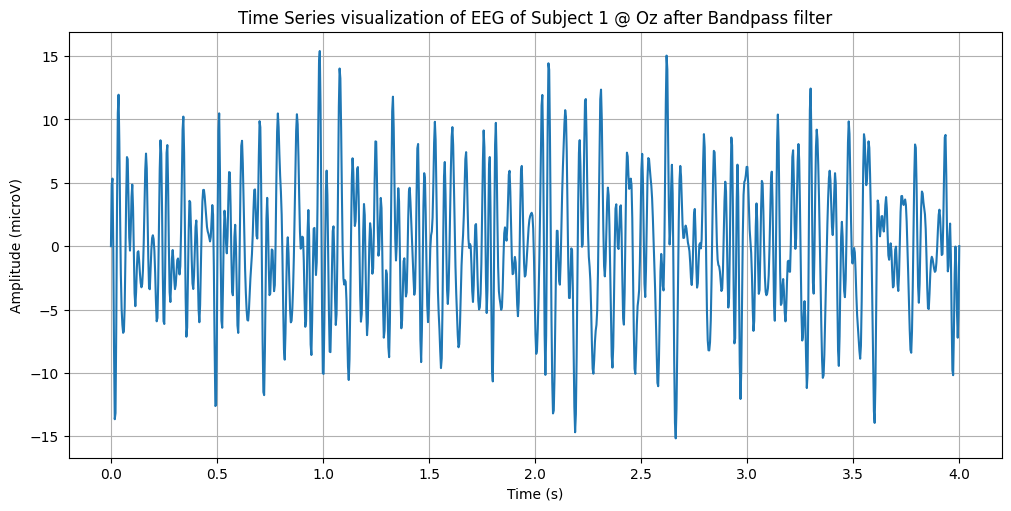

In [96]:
fig, ax = plt.subplots(figsize= (10,5), sharex=True, sharey=True, layout="constrained")
ax.plot(np.linspace(0, 4, 1114),subject1data[1].get_data()[1,7,:])
ax.grid(True)
ax.set_title("Time Series visualization of EEG of Subject 1 @ Oz after Bandpass filter")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (microV)")

## CCA

Reference Signals = [9.25, 11.25, 13.25, 9.75, 11.75, 13.75, 10.25, 12.25, 14.25, 10.75, 12.75, 14.75]

In [97]:
#To test if my CCA even works for the EEG data @ 9.25Hz
ref_freq = [9.25, 11.25, 13.25, 9.75, 11.75, 13.75, 10.25, 12.25, 14.25, 10.75, 12.75, 14.75]
harm_mult = [1,2,3,4]
reference_signal = np.zeros([len(ref_freq), 2 * len(harm_mult),n_points])
for idx, freq in enumerate(ref_freq):
    for hidx, harm in enumerate(harm_mult):
        reference_signal[idx][0 + 2 * hidx] = np.sin(2 * np.pi * freq * times)
        reference_signal[idx][1 + 2 *hidx] = np.cos(2 * np.pi * freq * times)

print(np.shape(reference_signal))

(12, 8, 1114)


In [98]:
#I'll now attempt to find covariance matrices
C_YY = reference_signal @ reference_signal.transpose(0,2,1)
print(np.shape(C_YY))

(12, 8, 8)


The idea is this, the dimension fo our data is (12, 15, 8, 1114). Now for every freq in  the first index, i should get a really high value when I CCA will 15 trials of that freq

In [99]:
corrected_subject1data = subject1data - np.mean(subject1data, axis=3, keepdims=True) # type: ignore

In [ ]:
#For targetfreq 9.25Hz
X = corrected_subject1data[0]
print("Dimension of X:", np.shape(X))

C_XX = X @ X.transpose(0,2,1)
print("Dimension of C_XX:", np.shape(C_XX))

Dimension of X: (15, 8, 1114)
Dimension of C_XX: (15, 8, 8)


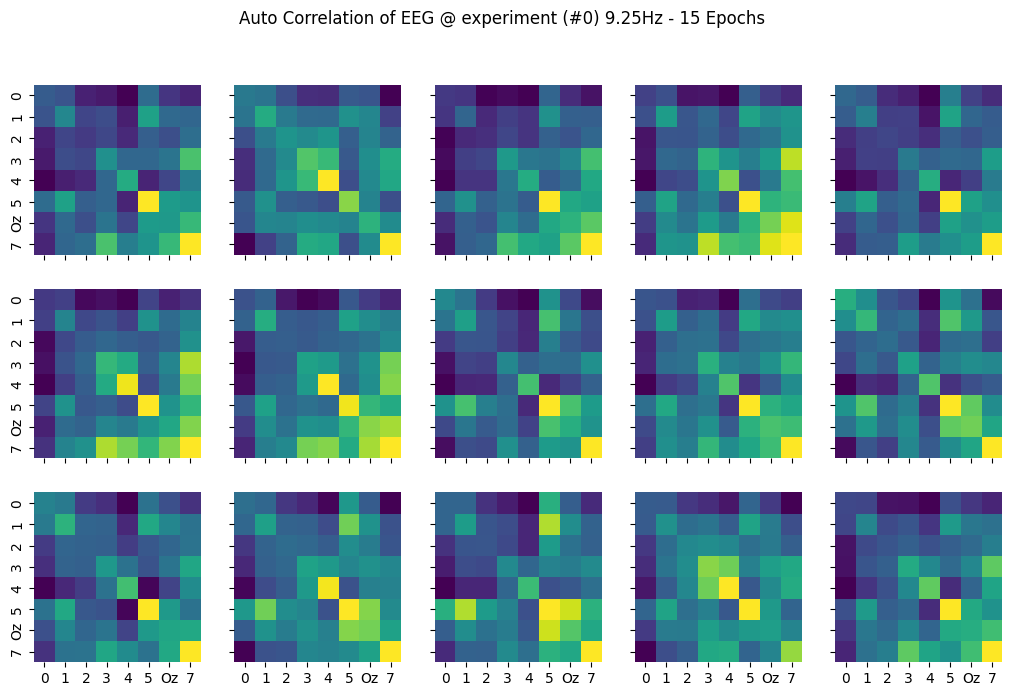

In [101]:
# 3 Rows and 5 Columns
fig, axes = plt.subplots(3,5, figsize = (5*2.5, 3*2.5), sharex=True, sharey=True)
fig.suptitle("Auto Correlation of EEG @ experiment (#0) 9.25Hz - 15 Epochs")
axes = axes.flatten()
for i in range(3 * 5):
        sns.heatmap(C_XX[i], ax=axes[i], cbar=False,robust=True, cmap='viridis', xticklabels=[0,1,2,3,4,5,"Oz",7], yticklabels=[0,1,2,3,4,5,"Oz",7]) # type: ignore

In [102]:
#Einstein summ or whatever
#(trials x channels x points) * (freq, harmonics, points) -> (trials, freq, channels, harmonics)
C_XY = np.einsum('tck, fhk -> tfch', X, reference_signal)
print("Dimension of C_XY:", np.shape(C_XY))

Dimension of C_XY: (15, 12, 8, 8)


<Axes: >

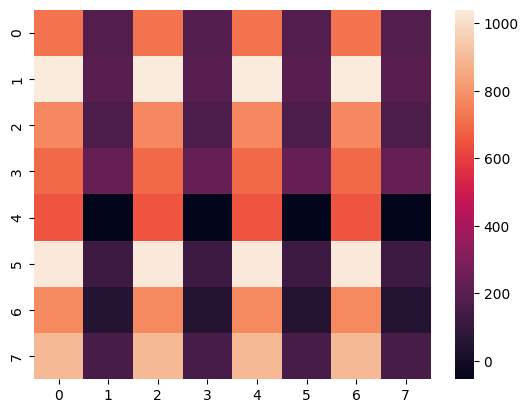

In [103]:
#Plotting a heatmap for 0th trial with 9.25Hz(#0 freq)
sns.heatmap(C_XY[0][4])

Computing the A matrix

In [104]:
RHO = np.zeros([15,12])
for i in range(15):
    for j in range(12):
        c_xx = C_XX[i]
        c_yy = C_YY[j]
        c_xy = C_XY[i][j]

        a = np.linalg.pinv(c_xx) @ c_xy @ np.linalg.pinv(c_yy) @ c_xy.T
        rho = np.linalg.eigvals(a)
        print(f"For trial {i}, matched with frequency {stim_freq[j], j}:", np.sqrt(np.max(rho.real)))
        RHO[i][j] = np.sqrt(np.max(rho.real))

For trial 0, matched with frequency (9.25, 0): 0.25955486380320864
For trial 0, matched with frequency (11.25, 1): 0.3299994797897535
For trial 0, matched with frequency (13.25, 2): 0.22327833535316427
For trial 0, matched with frequency (9.75, 3): 0.32745382924295635
For trial 0, matched with frequency (11.75, 4): 0.35766844870934994
For trial 0, matched with frequency (13.75, 5): 0.1580530279122458
For trial 0, matched with frequency (10.25, 6): 0.2481582298506298
For trial 0, matched with frequency (12.25, 7): 0.32349381211447675
For trial 0, matched with frequency (14.25, 8): 0.2397280683213656
For trial 0, matched with frequency (10.75, 9): 0.2684197526192423
For trial 0, matched with frequency (12.75, 10): 0.221554289703803
For trial 0, matched with frequency (14.75, 11): 0.1860911535661142
For trial 1, matched with frequency (9.25, 0): 0.28484624764678385
For trial 1, matched with frequency (11.25, 1): 0.37738952388665836
For trial 1, matched with frequency (13.25, 2): 0.1750814

<Axes: >

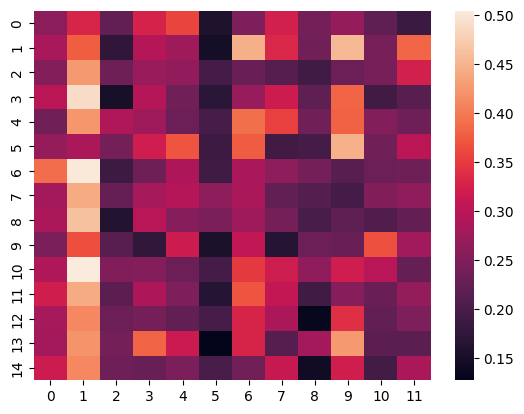

In [105]:
sns.heatmap(RHO)